<a href="https://colab.research.google.com/github/Jee8825/jeeva-codebooster-2026/blob/main/Day_2/Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('Student Performance.csv')
print(df.columns.to_list())

['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [4]:
conn= sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql('student_performance',conn,if_exists='replace',index=False)
cursor.execute("SELECT COUNT(*) FROM student_performance")
count=cursor.fetchone()[0]
print(f"Number of rows in the table: {count}")

Number of rows in the table: 30


In [ ]:
query1=""" Select student_id

In [5]:
def run_query(sql_string, description_label):
    print(f"\n--- {description_label} ---")
    query_df = pd.read_sql_query(sql_string, conn)
    display(query_df)
    print(f"Rows returned: {len(query_df)}")

In [8]:
query1=""" Select student_id, name
FROM student_performance LIMIT 5
"""
run_query(query1, "Students older than 19")


--- Students older than 19 ---


,student_id,name
0,1001,Aarav Sharma
1,1002,Priya Patel
2,1003,Rohit Verma
3,1004,Sneha Reddy
4,1005,Arjun Nair


Rows returned: 5


In [7]:
query2 = """SELECT department,
       AVG(math_score) AS avg_math_score,
       AVG(science_score) AS avg_science_score,
       AVG(english_score) AS avg_english_score,
       AVG(programming_score) AS avg_programming_score
FROM student_performance
GROUP BY department
ORDER BY department"""
run_query(query2, "Average scores per department")


--- Average scores per department ---


,department,avg_math_score,avg_science_score,avg_english_score,avg_programming_score
0,Civil,63.400000,66.600000,65.200000,40.600000
1,Computer Science,85.615385,84.461538,80.846154,89.230769
2,Electronics,71.000000,74.166667,70.833333,61.500000
3,Mechanical,71.000000,76.500000,70.500000,49.333333


Rows returned: 4


In [10]:
query3 = """SELECT student_id, name, department, math_score
FROM student_performance
ORDER BY math_score DESC
LIMIT 5"""
run_query(query3, "Top 5 students by math score")


--- Top 5 students by math score ---


,student_id,name,department,math_score
0,1010,Ananya Das,Computer Science,95
1,1022,Tanvi Mehta,Computer Science,93
2,1005,Arjun Nair,Computer Science,92
3,1030,Akanksha Yadav,Computer Science,91
4,1018,Swati Kulkarni,Computer Science,90


Rows returned: 5


In [11]:
query4 = """SELECT student_id, name, department, age
FROM student_performance
WHERE department = 'Computer Science'
ORDER BY name ASC"""
run_query(query4, "Computer Science Students (Alphabetical Order)")


--- Computer Science Students (Alphabetical Order) ---


,student_id,name,department,age
0,1001,Aarav Sharma,Computer Science,19
1,1015,Ajay Tiwari,Computer Science,19
2,1030,Akanksha Yadav,Computer Science,19
3,1025,Amit Bose,Computer Science,19
4,1010,Ananya Das,Computer Science,19
5,1005,Arjun Nair,Computer Science,19
6,1008,Divya Singh,Computer Science,19
7,1027,Gaurav Shukla,Computer Science,21
8,1020,Nisha Kapoor,Computer Science,19
9,1002,Priya Patel,Computer Science,20


Rows returned: 13


In [14]:
query5 = """SELECT name, math_score, programming_score, science_score, attendance_percentage
FROM student_performance WHERE department='Computer Science'
ORDER BY math_score ASC, programming_score ASC"""
run_query(query5, "Student scores and attendance (ordered by Math and Programming scores ASC)")


--- Student scores and attendance (ordered by Math and Programming scores ASC) ---


,name,math_score,programming_score,science_score,attendance_percentage
0,Ajay Tiwari,71,76,69,75
1,Priya Patel,76,79,82,87
2,Nisha Kapoor,79,83,84,89
3,Suresh Rao,83,88,86,88
4,Gaurav Shukla,84,87,79,87
5,Aarav Sharma,85,91,78,92
6,Amit Bose,86,89,82,91
7,Divya Singh,88,93,91,96
8,Swati Kulkarni,90,92,87,94
9,Akanksha Yadav,91,94,93,95


Rows returned: 13


In [20]:
query6="""SELECT department,
COUNT(*) AS num_students,
       AVG(math_score) AS avg_math_score,
       AVG(science_score) AS avg_science_score,
       AVG(english_score) AS avg_english_score,
       AVG(programming_score) AS avg_programming_score
FROM student_performance
GROUP BY department
ORDER BY avg_math_score DESC"""
run_query(query6, "Average Scores for All Subjects by Department")


--- Average Scores for All Subjects by Department ---


,department,num_students,avg_math_score,avg_science_score,avg_english_score,avg_programming_score
0,Computer Science,13,85.615385,84.461538,80.846154,89.230769
1,Mechanical,6,71.000000,76.500000,70.500000,49.333333
2,Electronics,6,71.000000,74.166667,70.833333,61.500000
3,Civil,5,63.400000,66.600000,65.200000,40.600000


Rows returned: 4


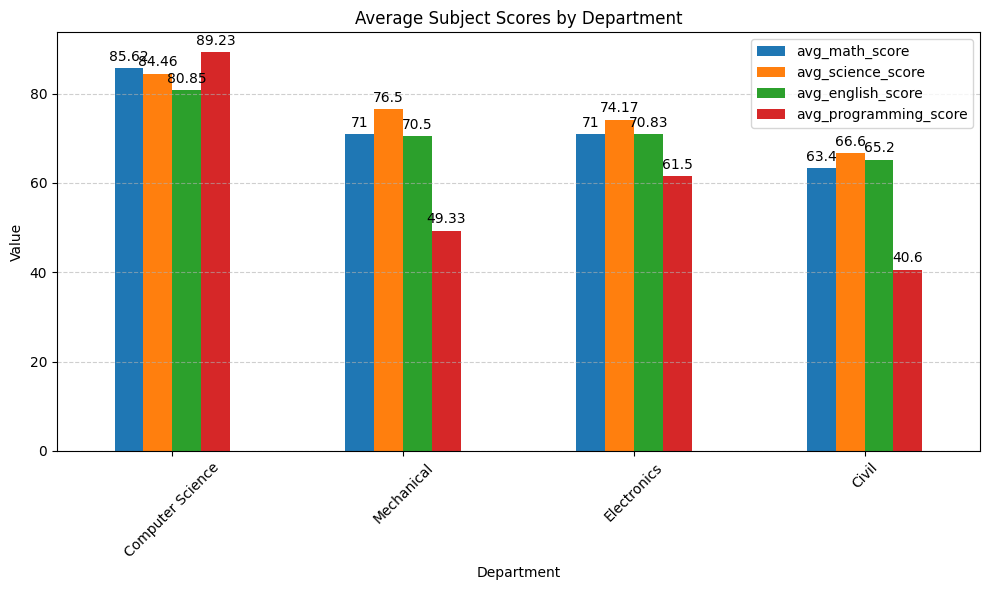

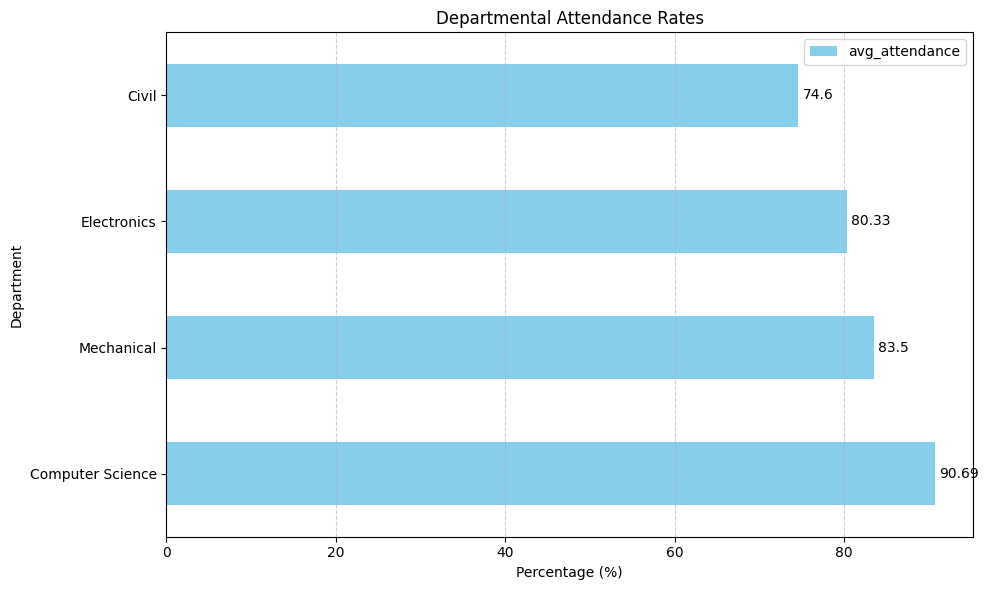

In [36]:
def visualize_query_results(sql_query, y_columns, title, kind='bar', color=None, ylabel='Value', orientation='v'):
    """
    A customizable function to execute a query and plot results.
    orientation: 'v' for vertical (default), 'h' for horizontal
    """
    plot_df = pd.read_sql_query(sql_query, conn)
    plot_df = plot_df.round(2)

    if 'department' in plot_df.columns:
        plot_df.set_index('department', inplace=True)

    # Determine plot kind based on orientation
    plot_kind = 'barh' if orientation == 'h' else kind

    ax = plot_df[y_columns].plot(kind=plot_kind, figsize=(10, 6), color=color)
    plt.title(title)

    if orientation == 'h':
        plt.xlabel(ylabel)
        plt.ylabel('Department')
    else:
        plt.ylabel(ylabel)
        plt.xlabel('Department')
        plt.xticks(rotation=45)

    plt.grid(axis='x' if orientation == 'h' else 'y', linestyle='--', alpha=0.6)

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.tight_layout()
    plt.show()

# Example usage for Subject Scores
subj_metrics = ['avg_math_score', 'avg_science_score', 'avg_english_score', 'avg_programming_score']
# Using a standard color list for subjects
visualize_query_results(query6, subj_metrics, "Average Subject Scores by Department", color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Attendance Chart with distinct colors for each department bar (horizontal)
multi_colors = ['skyblue', 'salmon', 'lightgreen', 'orange']
visualize_query_results(query7, ['avg_attendance'], "Departmental Attendance Rates", orientation='h', color=multi_colors, ylabel='Percentage (%)')


--- Average Attendance Percentage by Department ---


,department,avg_attendance
0,Computer Science,90.692308
1,Mechanical,83.500000
2,Electronics,80.333333
3,Civil,74.600000


Rows returned: 4


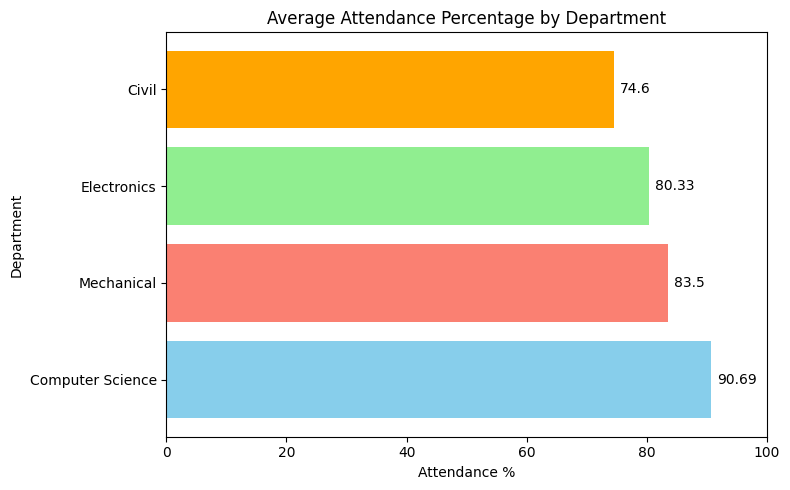

In [33]:
query7 = """SELECT department,
       AVG(attendance_percentage) AS avg_attendance
FROM student_performance
GROUP BY department
ORDER BY avg_attendance DESC"""
run_query(query7, "Average Attendance Percentage by Department")

query7_df = pd.read_sql_query(query7, conn)
query7_df['avg_attendance'] = query7_df['avg_attendance'].round(2)

plt.figure(figsize=(8, 5))

colors = ['skyblue', 'salmon', 'lightgreen', 'orange']

plt.barh(query7_df['department'], query7_df['avg_attendance'], color=colors)
plt.title('Average Attendance Percentage by Department')
plt.xlabel('Attendance %')
plt.ylabel('Department')
plt.xlim(0, 100)

for i, val in enumerate(query7_df['avg_attendance']):
    plt.text(val + 1, i, str(val), va='center')

plt.tight_layout()
plt.show()


--- Top 8 Students by Total Score ---


,name,total_score
0,Ananya Das,371
1,Tanvi Mehta,367
2,Akanksha Yadav,365
3,Arjun Nair,356
4,Divya Singh,356
5,Swati Kulkarni,354
6,Amit Bose,336
7,Suresh Rao,334


Rows returned: 8


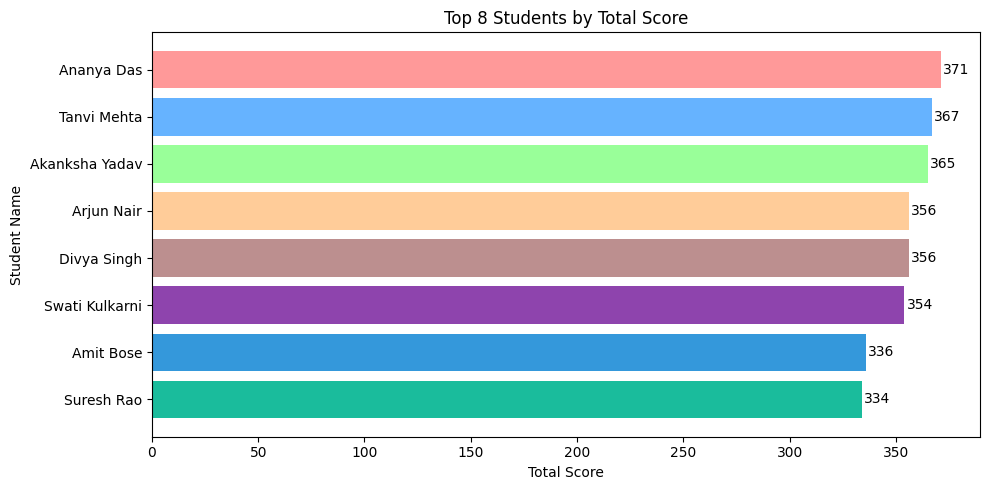


--- Average Attendance by Gender ---


,gender,avg_attendance
0,Female,88.533333
1,Male,80.466667


Rows returned: 2


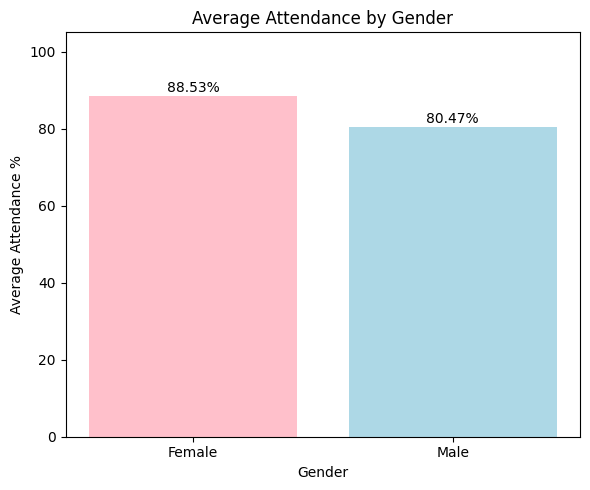

In [42]:
# ---- CUSTOMIZE COLORS HERE ----
top_student_colors = ['#FF9999', '#66B3FF', '#99FF99', '#FFCC99', '#BC8F8F', '#8E44AD', '#3498DB', '#1ABC9C']
gender_colors = ['#FFC0CB', '#ADD8E6']  # Pink for Female, LightBlue for Male
# -------------------------------

# 1. Query for Top 8 Students by Total Score
query_top_students = """
SELECT name,
       (math_score + science_score + english_score + programming_score) AS total_score
FROM student_performance
ORDER BY total_score DESC
LIMIT 8
"""
run_query(query_top_students, "Top 8 Students by Total Score")

# Visualize Top 8 Students
top_df = pd.read_sql_query(query_top_students, conn)
plt.figure(figsize=(10, 5))
plt.barh(top_df['name'], top_df['total_score'], color=top_student_colors)
plt.xlabel('Total Score')
plt.ylabel('Student Name')
plt.title('Top 8 Students by Total Score')
plt.gca().invert_yaxis()  # Highest score at the top

for i, val in enumerate(top_df['total_score']):
    plt.text(val + 1, i, str(val), va='center')

plt.tight_layout()
plt.show()

# 2. Query for Avg Attendance by Gender
query_gender_attn = """
SELECT gender,
       AVG(attendance_percentage) AS avg_attendance
FROM student_performance
GROUP BY gender
"""
run_query(query_gender_attn, "Average Attendance by Gender")

# Visualize Attendance by Gender
gender_df = pd.read_sql_query(query_gender_attn, conn)
plt.figure(figsize=(6, 5))
plt.bar(gender_df['gender'], gender_df['avg_attendance'], color=gender_colors)
plt.ylabel('Average Attendance %')
plt.xlabel('Gender')
plt.title('Average Attendance by Gender')
plt.ylim(0, 105)

for i, val in enumerate(gender_df['avg_attendance']):
    plt.text(i, val + 1, f"{val:.2f}%", ha='center')

plt.tight_layout()
plt.show()

In [40]:
sql_query_average_programming_score_for_female_students = """
SELECT AVG(programming_score) AS average_programming_score
FROM student_performance
WHERE gender = 'Female'
"""
run_query(sql_query_average_programming_score_for_female_students, "Average Programming Score for Female Students")


--- Average Programming Score for Female Students ---


,average_programming_score
0,70.2


Rows returned: 1


In [45]:
query_high_attendance = """
SELECT department,
       AVG(attendance_percentage) AS avg_attendance
FROM student_performance
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

run_query(query_high_attendance, "Departments with Average Attendance > 85%")


--- Departments with Average Attendance > 85% ---


,department,avg_attendance
0,Computer Science,90.692308


Rows returned: 1


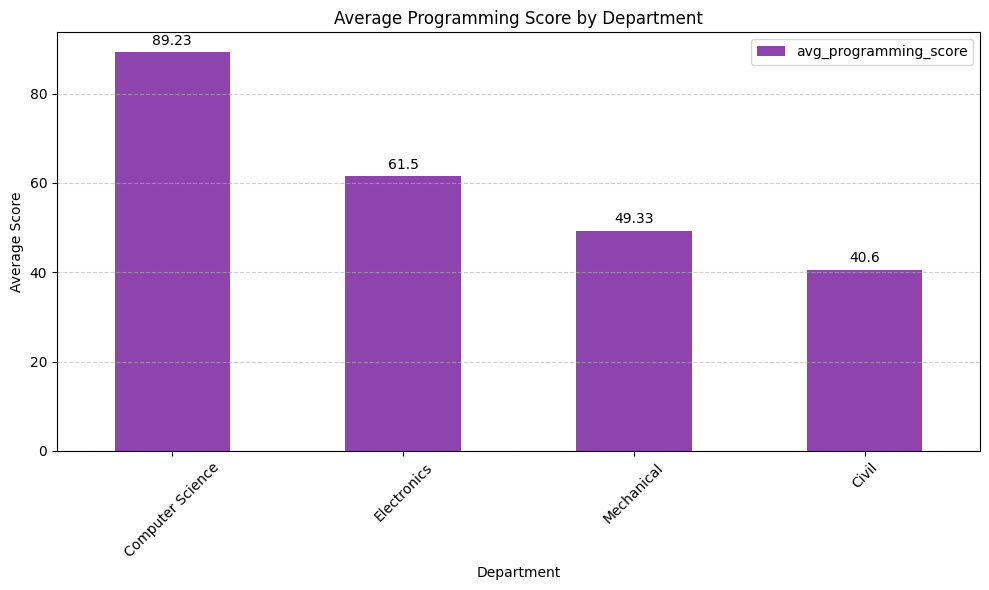

In [46]:
query_avg_prog = """SELECT department,
       AVG(programming_score) AS avg_programming_score
FROM student_performance
GROUP BY department
ORDER BY avg_programming_score DESC"""

visualize_query_results(
    query_avg_prog,
    ['avg_programming_score'],
    "Average Programming Score by Department",
    color='#8E44AD',
    ylabel='Average Score'
)